# SST Upwelling Binary Segmentation Video
Generates a daily binary segmentation video representing upwelling (SST $\le$ daily spatial mean - 1 $\sigma$) vs non-upwelling (SST > daily spatial mean - 1 $\sigma$).

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import warnings

# Create directory for videos
os.makedirs('videos', exist_ok=True)

In [2]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [ ]:
# 2. Process 7-day sliding window grids for 2018
from datetime import timedelta

df_2018 = df.loc['2018'].copy()
unique_dates = sorted(list(set(df_2018.index.date)))

dates = []
grids = []
thresholds = []

In [ ]:
# print("Processing 7-day sliding window grids for 2018...")
# for target_date in unique_dates:
#     start_date = target_date - timedelta(days=6)
    
#     # Get subset of dataframe for the 7-day window ending on target_date
#     window_df = df_2018.loc[str(start_date):str(target_date)]
    
#     window_grids = []
#     for _, row in window_df.iterrows():
#         grid = row.get('sst')
#         if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
#             window_grids.append(np.array(grid, dtype=float))
            
#     if not window_grids:
#         continue
        
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore', category=RuntimeWarning)
#         sst_grid = np.nanmean(np.stack(window_grids), axis=0)
        
#     # Calculate spatial mean and standard deviation for the window's averaged grid
#     mean_sst = np.nanmean(sst_grid)
#     std_sst = np.nanstd(sst_grid)
#     threshold = mean_sst - std_sst
    
#     seg_grid = np.zeros_like(sst_grid)
#     target_mask = sst_grid <= threshold
#     seg_grid[target_mask] = 1
    
#     # Preserve NaNs
#     seg_grid[np.isnan(sst_grid)] = np.nan
        
#     dates.append(target_date)
#     grids.append(seg_grid)
#     thresholds.append(threshold)

In [4]:
# # 3. Create Video Animation
# print(f"Generating video with {len(grids)} frames...")
# fig, ax = plt.subplots(figsize=(8, 6))

# # Binary map colors: Other=Blue, Target=Red
# cmap = mcolors.ListedColormap(['blue', 'red'])
# cmap.set_bad('grey') # Color for NaNs (land/missing)
# bounds = [-0.5, 0.5, 1.5]
# norm = mcolors.BoundaryNorm(bounds, cmap.N)

# cax = ax.imshow(grids[0] if grids else np.zeros((10,10)), cmap=cmap, norm=norm, origin='lower', animated=True)
# cbar = fig.colorbar(cax, ax=ax, ticks=[0, 1])
# cbar.ax.set_yticklabels(['Other', 'Upwelling (\u2264 -1 std)'])

# title = ax.set_title('')

# def update(frame_idx):
#     cax.set_array(grids[frame_idx])
#     title.set_text(f'SST Upwelling Segmentation - {dates[frame_idx]}\nThreshold: \u2264 {thresholds[frame_idx]:.2f}\u00b0C (7-day mean - 1 \u03c3)')
#     return cax, title

# if grids:
#     ani = FuncAnimation(fig, update, frames=len(grids), blit=False)
#     video_path = 'videos/sst_upwelling_2018_7day_window.mp4'
    
#     try:
#         ani.save(video_path, fps=10, writer='ffmpeg')
#         print(f"Video successfully saved to {video_path}")
#     except RuntimeError as e:
#         print("Could not save mp4 via ffmpeg. Attempting fallback to save via pillow as a GIF...")
#         gif_path = video_path.replace('.mp4', '.gif')
#         ani.save(gif_path, fps=10, writer='pillow')
#         print(f"Video saved as GIF instead at {gif_path}")
# plt.close()

In [17]:
# Plot Monthly 3x4 Grid of Binary Upwelling Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [18]:
# Extract coordinates from metadata
lon_centers = np.array(data['metadata']['lon_centers'])
lat_centers = np.array(data['metadata']['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

months = range(1, 13)
month_names_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']

monthly_binary = {}

In [ ]:
# Compute monthly means and their binary upwelling threshold 
for m in months:
    month_rows = df_2018[df_2018.index.month == m]
    month_grids = []
    for _, row in month_rows.iterrows():
        grid = row.get('sst')
        if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
            month_grids.append(np.array(grid, dtype=float))
            
    if month_grids:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
            
        spatial_mean = np.nanmean(mean_month_sst)
        spatial_std = np.nanstd(mean_month_sst)
        threshold = spatial_mean - spatial_std
        
        binary_grid = np.zeros_like(mean_month_sst)
        binary_grid[mean_month_sst <= threshold] = 1
        binary_grid[np.isnan(mean_month_sst)] = np.nan
        monthly_binary[m] = binary_grid
    else:
        monthly_binary[m] = None


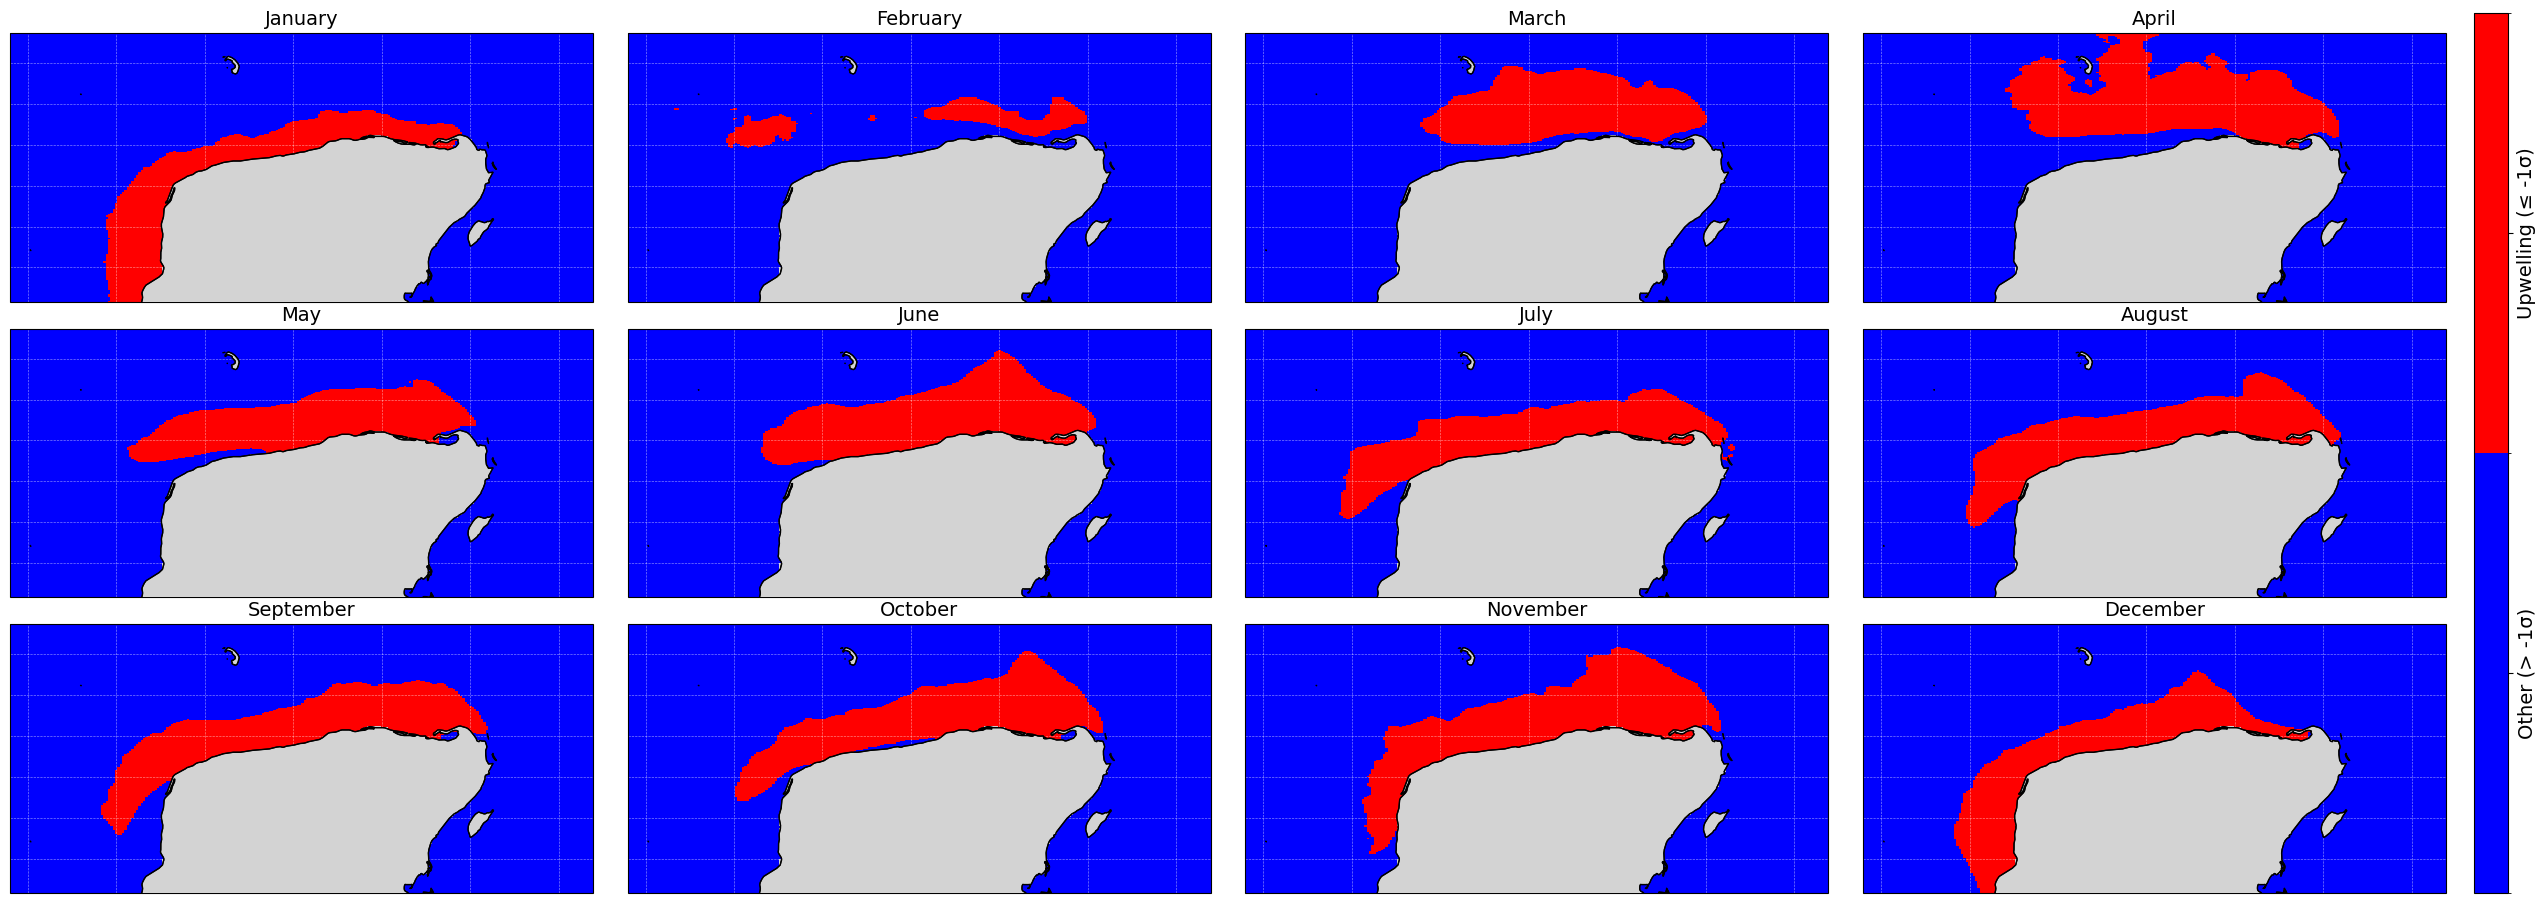

In [24]:
# Region extent
lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256

fig, axes = plt.subplots(3, 4, figsize=(28, 10), subplot_kw={'projection': ccrs.PlateCarree()})

cmap = mcolors.ListedColormap(['blue', 'red'])
cmap.set_bad('lightgray') # Color for NaNs (land/missing)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

mesh_for_cbar = None

for month_num, ax in enumerate(axes.ravel(), start=1):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    try:
        ax.set_aspect('auto')
    except Exception:
        pass

    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)
    
    data_grid = monthly_binary.get(month_num)
    
    if data_grid is None:
        ax.set_title(f"{month_names_full[month_num-1]}\nNo Data", fontsize=14)
        continue
        
    mesh = ax.pcolormesh(
        lon_grid_2d, lat_grid_2d, data_grid,
        cmap=cmap, transform=ccrs.PlateCarree(),
        norm=norm, shading='auto', zorder=1
    )
    
    if mesh_for_cbar is None:
        mesh_for_cbar = mesh
        
    ax.set_title(f"{month_names_full[month_num-1]}", fontsize=14)

# Shared Colorbar
fig.subplots_adjust(left=0.03, right=0.90, bottom=0.04, top=0.9, wspace=0.06, hspace=0.1)
if mesh_for_cbar is not None:
                    # left, bottom, width, height
    cax = fig.add_axes([0.91, 0.04, 0.012, 0.88])
    cbar = fig.colorbar(mesh_for_cbar, cax=cax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Other (> -1\u03c3)', 'Upwelling (\u2264 -1\u03c3)'], fontsize=14, rotation=90, va='center')

# fig.suptitle('Monthly Mean SST Upwelling Binary Maps (Jan–Dec, 2018)', fontsize=22, y=0.97)
plt.show()

make graph start at 0
trim edges
cdom vs. chloro
